# 04. 변동성(가격 위험) 예측

01에서 수익률의 방향은 이어지지 않지만 **크기는 이어진다**(변동성 군집)는 것을 봤다. 03에서는 방향 예측이 구매 결정에 큰 도움이 되지 않았다. 카페에게 더 쓸모 있는 질문은 "앞으로 몇 주, 몇 달 동안 가격이 얼마나 크게 흔들릴까"일 수 있다. 크게 흔들릴 것 같으면 일부를 미리 사서 위험을 줄일 수 있다.

예측 대상은 앞으로 h거래일(5·20·60) 동안 일간 로그수익률의 표준편차의 로그 $v_h$ 다.

| 모델 | 설명 |
|---|---|
| 직전 변동성 | 지난 h일 변동성이 그대로 간다 (기준선) |
| 장기 평균 | 학습 구간 평균 (기준선) |
| HAR | 지난 5·20·60일 변동성(로그)의 선형 결합. 변동성 예측의 대표적인 단순 모델 |
| HAR+기후·거시 | HAR에 기후·거시 피처를 더한 Ridge |
| LightGBM | HAR 피처와 전체 피처의 트리 모델 |

선택 규칙: 개발 구간(2012–2021) walk-forward RMSE가 가장 낮은 모델을 쓴다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

import common
from coffee.config import DEV_YEARS, HOLDOUT_YEARS, HORIZONS
from coffee.evaluate import block_bootstrap_rmse_diff, fold_rows
from coffee.features import ALL_FEATURES, FEATURE_GROUPS, build_dataset
from coffee.models import LightGBMModel, RidgeModel, return_model
from coffee.sources import load_sources

data = build_dataset(load_sources())
HAR = ["log_vol_5", "log_vol_20", "log_vol_60"]


class PastVol:
    name, features = "직전 변동성", []

    def __init__(self, h):
        self.h = h

    def fit(self, data, rows, y):
        return self

    def predict(self, data, rows):
        return data[f"log_vol_{self.h}"].to_numpy()[rows]


class LongRunMean:
    name, features = "장기 평균", []

    def fit(self, data, rows, y):
        self.mean_ = float(np.mean(y))
        return self

    def predict(self, data, rows):
        return np.full(len(rows), self.mean_)


def candidates(h):
    return {
        "직전 변동성": lambda: PastVol(h),
        "장기 평균": lambda: LongRunMean(),
        "HAR": lambda: RidgeModel(HAR, alpha=1),
        "HAR+기후·거시": lambda: RidgeModel(HAR + FEATURE_GROUPS["climate"] + FEATURE_GROUPS["macro"], alpha=10),
        "LightGBM": lambda: LightGBMModel(HAR + ALL_FEATURES, n_estimators=200, num_leaves=7, min_child_samples=100),
    }


def walk_forward(h, make, years):
    target = f"v_{h}"
    y = data[target].to_numpy()
    out = {"y": [], "pred": [], "rows": []}
    for year in years:
        fit, test = fold_rows(data, ALL_FEATURES, h, year, years[-1], target=target)
        out["pred"].append(make().fit(data, fit, y[fit]).predict(data, test))
        out["y"].append(y[test])
        out["rows"].append(test)
    return {key: np.concatenate(value) for key, value in out.items()}

## 1. 개발 구간 비교

In [2]:
dev, rows = {}, []
for h in HORIZONS:
    for name, make in candidates(h).items():
        dev[h, name] = walk_forward(h, make, DEV_YEARS)
    past = dev[h, "직전 변동성"]
    for name in candidates(h):
        result = dev[h, name]
        rmse = np.sqrt(np.mean((result["y"] - result["pred"]) ** 2))
        interval = block_bootstrap_rmse_diff(result["y"], result["pred"], past["pred"], block=h)
        rows.append({"지평": h, "모델": name, "RMSE(로그)": rmse,
                     "직전 변동성 대비(%)": 100 * (rmse / np.sqrt(np.mean((past["y"] - past["pred"]) ** 2)) - 1),
                     "차이 95% 구간": f"[{interval['low']:+.4f}, {interval['high']:+.4f}]",
                     "상관": np.corrcoef(result["y"], result["pred"])[0, 1]})
comparison = pd.DataFrame(rows)
selection = {h: comparison[comparison["지평"] == h].set_index("모델")["RMSE(로그)"].idxmin() for h in HORIZONS}
print("선택:", selection)
comparison.set_index(["지평", "모델"]).round(4)

선택: {5: 'HAR', 20: 'HAR', 60: 'HAR'}


RMSE(로그)  직전 변동성 대비(%)           차이 95% 구간      상관
지평 모델                                                           
5  직전 변동성       0.6137        0.0000  [+0.0000, +0.0000]  0.2063
   장기 평균        0.4933      -19.6286  [-0.1457, -0.0940] -0.1636
   HAR          0.4625      -24.6319  [-0.1723, -0.1273]  0.3195
   HAR+기후·거시    0.4892      -20.2860  [-0.1488, -0.0994]  0.1573
   LightGBM     0.4733      -22.8805  [-0.1640, -0.1156]  0.2603
20 직전 변동성       0.3054        0.0000  [+0.0000, +0.0000]  0.4376
   장기 평균        0.2988       -2.1831  [-0.0490, +0.0319] -0.2600
   HAR          0.2630      -13.8840  [-0.0694, -0.0180]  0.4248
   HAR+기후·거시    0.3067        0.4067  [-0.0364, +0.0386]  0.1936
   LightGBM     0.2761       -9.6001  [-0.0636, +0.0001]  0.3334
60 직전 변동성       0.2340        0.0000  [+0.0000, +0.0000]  0.5066
   장기 평균        0.2459        5.0859  [-0.0317, +0.0566] -0.3846
   HAR          0.2187       -6.5368  [-0.0469, +0.0174]  0.3896
   HAR+기후·거시    0.2459        5.0837  [-0.0202, +0.0439]  0.1783
   LightGBM     0.2427        3.7471  [-0.0279, +0.0424]  0.2035

**HAR이 세 지평 모두 가장 정확했다.** 5일은 직전 변동성보다 RMSE가 25% 낮고 장기 평균(−20%)보다도 나으며, 블록 bootstrap 구간이 0을 포함하지 않는다. 20일은 14% 낮고 구간이 0을 포함하지 않는다. 60일은 7% 낮지만 구간이 0을 포함한다. 수익률 예측(03)과 달리, 변동성에서는 단순한 모델이 기준선을 분명히 이긴다. 기후·거시 피처를 더하면 오히려 나빠졌고, 트리 모델도 HAR보다 못했다. 변동성은 과거 변동성 자체에 대부분의 정보가 있다.

## 2. 보류 구간(2022–2025)

In [3]:
holdout, rows = {}, []
for h in HORIZONS:
    for name in ("직전 변동성", "장기 평균", selection[h]):
        holdout[h, name] = walk_forward(h, candidates(h)[name], HOLDOUT_YEARS)
    past = holdout[h, "직전 변동성"]
    for name in dict.fromkeys(("직전 변동성", "장기 평균", selection[h])):
        result = holdout[h, name]
        rmse = np.sqrt(np.mean((result["y"] - result["pred"]) ** 2))
        rows.append({"지평": h, "모델": name, "RMSE(로그)": rmse,
                     "직전 변동성 대비(%)": 100 * (rmse / np.sqrt(np.mean((past["y"] - past["pred"]) ** 2)) - 1),
                     "상관": np.corrcoef(result["y"], result["pred"])[0, 1]})
holdout_table = pd.DataFrame(rows)
holdout_table.set_index(["지평", "모델"]).round(4)

RMSE(로그)  직전 변동성 대비(%)      상관
지평 모델                                    
5  직전 변동성    0.5797        0.0000 -0.0028
   장기 평균     0.4502      -22.3360  0.0018
   HAR       0.4220      -27.2094  0.0516
20 직전 변동성    0.2817        0.0000 -0.0405
   장기 평균     0.2604       -7.5783  0.0395
   HAR       0.2250      -20.1353 -0.0209
60 직전 변동성    0.1624        0.0000 -0.1226
   장기 평균     0.2076       27.8308  0.1134
   HAR       0.1656        1.9252 -0.0842

보류 구간에서 HAR은 직전 변동성보다 5일 27%, 20일 20% 정확했지만, 60일은 오히려 2% 나빴다. 세 지평 모두 예측과 실제의 상관은 거의 0이다. 2022–2025년은 변동성이 연율 35~40%로 내내 높았던 시기라, HAR의 이득은 날마다의 변화를 따라간 데서가 아니라 수준을 평균 쪽으로 당긴 데서 나왔다(아래 그림).

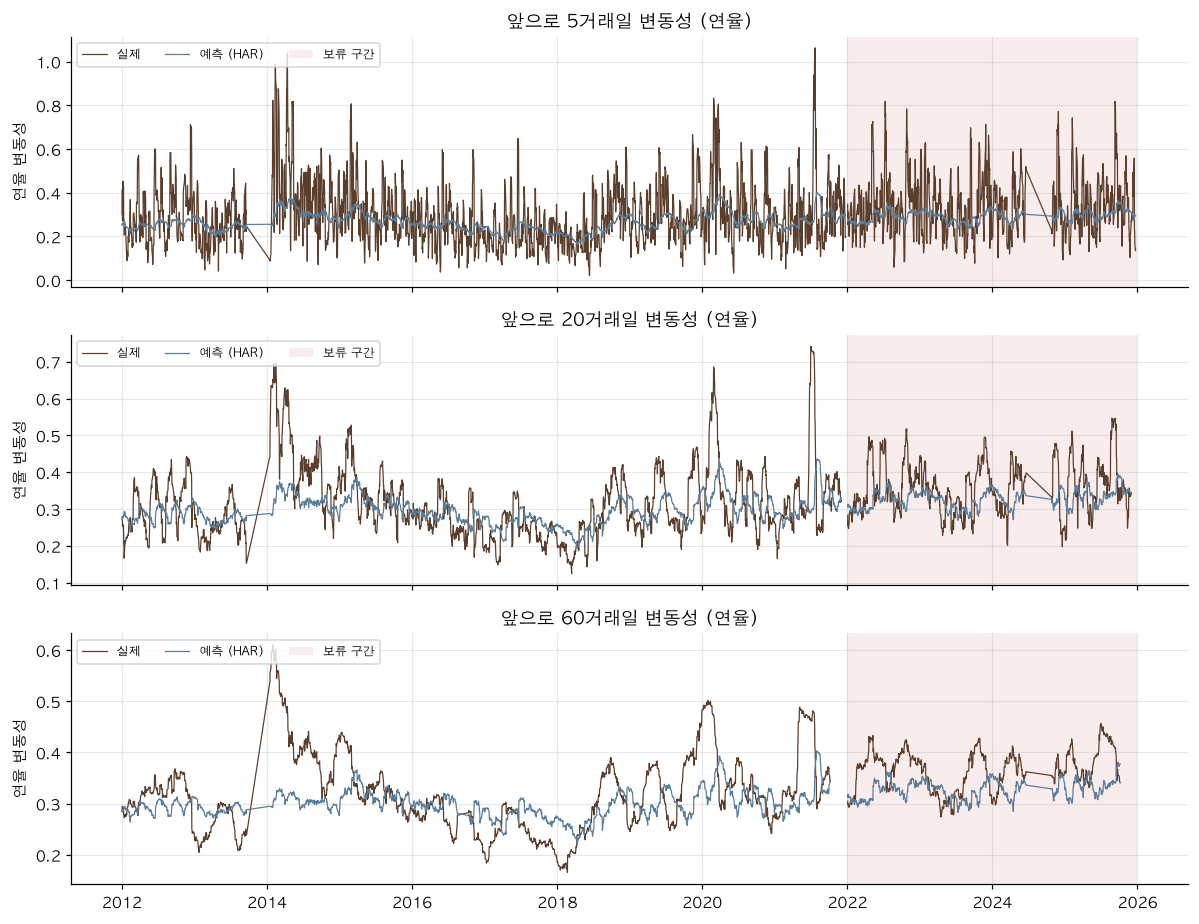

In [4]:
annual = np.sqrt(252)
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(11, 8.5), sharex=True)
for ax, h in zip(axes, HORIZONS):
    for label, years, store in (("개발", DEV_YEARS, dev), ("보류", HOLDOUT_YEARS, holdout)):
        result = store[h, selection[h]]
        dates = data.index[result["rows"]]
        ax.plot(dates, np.exp(result["y"]) * annual, color="#5a3e2b", lw=0.8, label="실제" if label == "개발" else None)
        ax.plot(dates, np.exp(result["pred"]) * annual, color="#5a7d9a", lw=0.8, label=f"예측 ({selection[h]})" if label == "개발" else None)
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2025-12-31"), color="#f6e0e0", alpha=0.6, lw=0, label="보류 구간")
    ax.set(title=f"앞으로 {h}거래일 변동성 (연율)", ylabel="연율 변동성")
    ax.legend(loc="upper left", fontsize=8, ncol=3)
fig.tight_layout()
common.save_fig(fig, "volatility_forecast.png")
plt.show()

2011–2014년과 2021년처럼 변동성이 크게 오르내린 시기에는 예측이 실제를 뒤따라가지만, 급등 시점을 미리 잡지는 못한다. 변동성 예측도 '지금 높으면 한동안 높다'는 정도의 정보다.

## 3. 예상 가격 범위

예측 변동성으로 h거래일 뒤 가격의 80% 범위를 만든다: $P_t \cdot \exp(\hat r \pm 1.28 \cdot k \cdot \hat\sigma \sqrt{h})$. 가운데 $\hat r$은 03에서 고른 수익률 모델의 예측이다. 서비스는 예측 가격을 가운데에 둔 범위를 보여 준다. 로그 변동성 예측은 평균을 조금 낮게 잡는 경향이 있고 수익률 예측에도 오차가 있으므로, 배율 $k$를 개발 구간에서 정한다(실제 가격이 범위 안에 들어간 비율이 80%가 되게). 보류 구간에서는 그 $k$를 그대로 쓴다. 비교를 위해 현재가를 가운데에 둔 범위($\hat r = 0$)도 같은 방식으로 계산한다.

In [5]:
z = norm.ppf(0.9)
return_choice = {int(h): value for h, value in common.load_result("return_selection").items()}


def return_walk_forward(h, years):
    # 03과 같은 방식으로 연도마다 다시 학습한 수익률 예측. 행 번호 → 예측 로그수익률
    choice, y = return_choice[h], data[f"y_{h}"].to_numpy()
    preds = []
    for year in years:
        fit, test = fold_rows(data, ALL_FEATURES, h, year, years[-1])
        model = return_model(choice["model"], choice["features"], h).fit(data, fit, y[fit])
        preds.append(pd.Series(model.predict(data, test), index=test))
    return pd.concat(preds)


def coverage(h, result, k, center=None):
    sigma = np.exp(result["pred"]) * np.sqrt(h) * k
    actual = data[f"y_{h}"].to_numpy()[result["rows"]]
    if center is not None:  # 수익률 예측을 가운데에 둔다. 예측이 없는 행은 뺀다
        actual = actual - center.reindex(result["rows"]).to_numpy()
    valid = ~np.isnan(actual)
    return float(np.mean(np.abs(actual[valid]) <= z * sigma[valid]))


def fit_multiplier(h, result, center=None):
    grid = np.linspace(0.8, 1.6, 81)
    return float(grid[np.argmin([abs(coverage(h, result, k, center) - 0.8) for k in grid])])


centers = {(h, label): return_walk_forward(h, years) for h in HORIZONS
           for label, years in (("개발", DEV_YEARS), ("보류", HOLDOUT_YEARS))}
multipliers, naive_multipliers, rows = {}, {}, []
for h in HORIZONS:
    multipliers[h] = fit_multiplier(h, dev[h, selection[h]], centers[h, "개발"])
    naive_multipliers[h] = fit_multiplier(h, dev[h, selection[h]])
    for label, store in (("개발", dev), ("보류", holdout)):
        rows.append({"지평": h, "구간": label,
                     "예측 가격 중심 (서비스)": coverage(h, store[h, selection[h]], multipliers[h], centers[h, label]),
                     "현재가 중심": coverage(h, store[h, selection[h]], naive_multipliers[h]),
                     "직전 변동성, 현재가 중심 (k=1)": coverage(h, store[h, "직전 변동성"], 1.0)})
print("배율 k (예측 가격 중심):", multipliers)
print("배율 k (현재가 중심):", naive_multipliers)
range_table = pd.DataFrame(rows)
range_table.set_index(["지평", "구간"]).round(3)

배율 k (예측 가격 중심): {5: 1.2000000000000002, 20: 1.06, 60: 0.9500000000000001}
배율 k (현재가 중심): {5: 1.21, 20: 1.0, 60: 0.89}


예측 가격 중심 (서비스)  현재가 중심  직전 변동성, 현재가 중심 (k=1)
지평 구간                                              
5  개발           0.801   0.802                 0.716
   보류           0.779   0.777                 0.721
20 개발           0.801   0.801                 0.805
   보류           0.760   0.762                 0.782
60 개발           0.803   0.801                 0.874
   보류           0.700   0.697                 0.792

예측 가격을 가운데에 둔 범위의 배율은 5 / 20 / 60일 1.20 / 1.06 / 0.95로 정해졌다. 개발 구간에서 80%가 되도록 정한 이 범위가 보류 구간에서는 78% / 76% / 70%만 맞았다. 현재가를 가운데에 둔 범위와 거의 같은데, 수익률 예측이 0에서 크게 벗어나지 않기 때문이다. 20·60일은 직전 변동성으로 만든 범위(k = 1)가 78%, 79%로 오히려 목표에 가까웠다(5일은 72%로 더 낮았다). HAR은 높은 변동성을 평균 쪽으로 당기기 때문에, 변동성이 내내 높았던 이 시기에는 범위를 좁게 잡았다. 대시보드의 예상 범위는 보장이 아니라 참고 구간으로 표시하고, 실제 적중률을 함께 기록한다.

## 4. 위험 수준

예측 변동성을 학습 구간 실제 변동성의 분포와 비교해 '낮음(하위 1/3) / 보통 / 높음(상위 1/3)'으로 나눈다. 위험 수준이 높다고 예측한 날에 실제로 가격이 더 크게 움직였는지 보류 구간에서 확인한다.

In [6]:
rows = []
for h in HORIZONS:
    fit, _ = fold_rows(data, ALL_FEATURES, h, HOLDOUT_YEARS[0], HOLDOUT_YEARS[-1], target=f"v_{h}")
    low, high = np.quantile(data[f"v_{h}"].to_numpy()[fit], [1 / 3, 2 / 3])
    result = holdout[h, selection[h]]
    level = np.where(result["pred"] < low, "낮음", np.where(result["pred"] > high, "높음", "보통"))
    moves = np.abs(data[f"y_{h}"].to_numpy()[result["rows"]])
    for name in ("낮음", "보통", "높음"):
        mask = level == name
        rows.append({"지평": h, "위험 수준": name, "날 비율": mask.mean(),
                     "실제 변동성(연율)": float(np.exp(result["y"][mask]).mean() * annual) if mask.any() else np.nan,
                     f"실제 |수익률| 평균": float(np.nanmean(moves[mask])) if mask.any() else np.nan})
risk = pd.DataFrame(rows)
risk.set_index(["지평", "위험 수준"]).round(3)

날 비율  실제 변동성(연율)  실제 |수익률| 평균
지평 위험 수준                                
5  낮음     0.000         NaN          NaN
   보통     0.865       0.342        0.042
   높음     0.135       0.337        0.032
20 낮음     0.000         NaN          NaN
   보통     0.504       0.359        0.092
   높음     0.496       0.361        0.070
60 낮음     0.000         NaN          NaN
   보통     0.443       0.368        0.141
   높음     0.557       0.364        0.132

학습 기간 전체의 분포로 위험 수준을 나누니 보류 구간은 전부 '보통·높음'이 됐고, 단계별 실제 변동 폭에도 차이가 거의 없었다. 고변동 국면에서는 '역대 대비' 기준이 정보를 잃는다. 그래서 서비스의 위험 수준은 **최근 3년 대비 예측 변동성의 위치(백분위)**로 표시한다. 기상 평년값을 이동 기준으로 바꾼 것과 같은 이유다.

In [7]:
common.save_result("volatility_selection", {str(h): {"model": selection[h], "interval_multiplier": multipliers[h],
                                                     "har_features": HAR} for h in HORIZONS})
common.save_result("volatility_results", {"dev": comparison.round(5).to_dict("records"),
                                           "holdout": holdout_table.round(5).to_dict("records"),
                                           "range_coverage": range_table.round(5).to_dict("records"),
                                           "risk": risk.round(5).to_dict("records")})

## 정리

- 5·20일 변동성은 단순한 HAR 모델이 기준선을 이긴다(5일 개발 −25%·보류 −27%, 20일 개발 −14%·보류 −20%). 이 프로젝트에서 기준선을 분명히 넘은 예측은 이 둘뿐이다.
- 60일 변동성은 개발 구간에서도 구간이 0을 포함했고, 보류 구간에서는 직전 변동성보다 2% 나빴다. 선택 규칙대로 HAR을 쓰지만, 60일 범위가 기준선보다 낫다고 말할 수는 없다.
- 고변동 국면(2022–2025)에서는 예측이 변화를 따라가기보다 수준만 맞췄고, 80% 범위의 실제 적중률은 70~78%였다.
- 서비스에는 HAR 변동성과 03의 수익률 예측으로 만든 예상 가격 범위(예측 가격이 가운데)와, 최근 3년 대비 변동성 위치를 보여 준다.